# Notebook 04 — Capas vectoriales con `geopandas`

Cargamos los 3 GeoJSON (región, POIs, rutas) y los visualizamos sobre el RGB de Sentinel-2 con `geopandas`.

**Salidas**: `media/04_vectors.png`, `media/04_vectors_separate.png`

In [1]:
from pathlib import Path
import os
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def find_taller_root(start: Path, marker: str = "python/data/bogota_sabana_sentinel2.tif") -> Path:
    p = start.resolve()
    for parent in [p, *p.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"No se encontró {marker} desde {start}")

ROOT = find_taller_root(Path.cwd())
os.chdir(ROOT)
DATA = ROOT / "python" / "data"
MEDIA = ROOT / "media"
MEDIA.mkdir(exist_ok=True)
print("Cargando capas vectoriales...")
region = gpd.read_file(DATA / "region.geojson")
pois = gpd.read_file(DATA / "puntos_interes.geojson")
rutas = gpd.read_file(DATA / "rutas.geojson")
print(f"  region: {len(region)} features, CRS={region.crs}")
print(f"  pois:   {len(pois)} features, CRS={pois.crs}")
print(f"  rutas:  {len(rutas)} features, CRS={rutas.crs}")
print()
print("POIs (head):")
print(pois.head().to_string())
print()
print("Rutas (head):")
print(rutas.head().to_string())

Cargando capas vectoriales...
  region: 1 features, CRS=EPSG:4326
  pois:   5 features, CRS=EPSG:4326
  rutas:  30 features, CRS=EPSG:4326

POIs (head):
                              name      tourism                   geometry
0        Museo Iglesia Santa Clara       museum  POINT (-74.07746 4.59684)
1  Entrada de Horizontes-Las Moyas   attraction  POINT (-74.04654 4.65939)
2                  Bogotá Marriott        hotel  POINT (-74.10857 4.65954)
3                 Hotel Tequendama        hotel  POINT (-74.07057 4.61291)
4    Centro Comercial Puerto López  information  POINT (-74.10145 4.61698)

Rutas (head):
                name    highway      length                                                                                                                                                                                                                     geometry
0   Avenida Calle 85  secondary   17.191568                                                                          

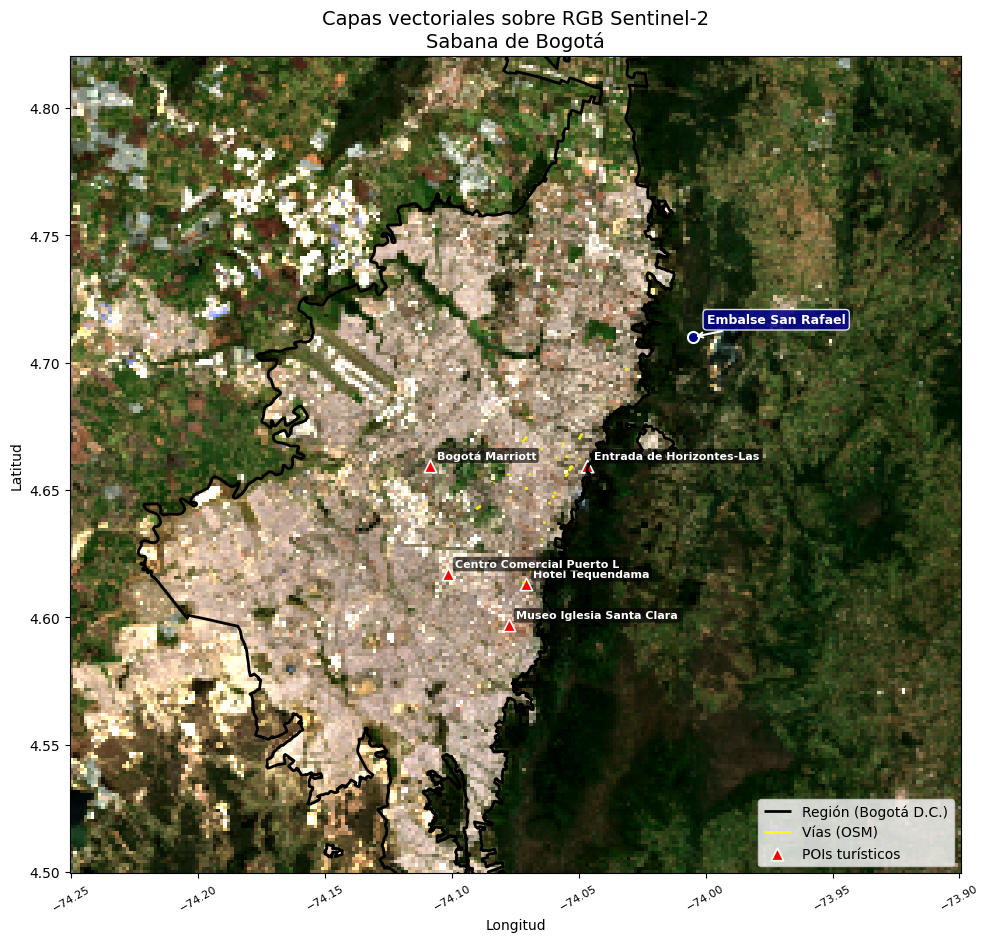

Guardado: /home/bellic12/Desktop/Visual/Semana_13_SLAM_Robotica_Visual/semana_13_2_mapas_interactivos_datos_satelitales/media/04_vectors.png


In [2]:
tif = DATA / "bogota_sabana_sentinel2.tif"
with rasterio.open(tif) as src:
    b02 = src.read(1).astype(np.float32)
    b03 = src.read(2).astype(np.float32)
    b04 = src.read(3).astype(np.float32)
    bounds = src.bounds

rgb = np.stack([b04, b03, b02], axis=-1)
vmin, vmax = np.nanpercentile(rgb, [2, 98])
rgb_stretched = np.clip((rgb - vmin) / (vmax - vmin), 0, 1)

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(
    rgb_stretched,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
)
region.boundary.plot(ax=ax, edgecolor="black", linewidth=2, label="Región (Bogotá D.C.)")
rutas.plot(ax=ax, color="yellow", linewidth=2, alpha=0.9, label="Vías (OSM)")
pois.plot(ax=ax, color="red", markersize=80, marker="^", edgecolor="white", linewidth=1.2, label="POIs turísticos")

for _, row in pois.iterrows():
    x, y = row.geometry.x, row.geometry.y
    name = row.get("name") or row.get("tourism", "POI")
    ax.annotate(str(name)[:25] if name is not None and not (isinstance(name, float) and str(name) == "nan") else "(sin nombre)", (x, y), xytext=(5, 5), textcoords="offset points",
                fontsize=8, color="white", weight="bold",
                bbox=dict(boxstyle="round,pad=0.2", fc="black", ec="none", alpha=0.6))

# Embalse San Rafael (cuerpo de agua visible como NDVI bajo en la esquina NE)
ax.annotate(
    "Embalse San Rafael",
    xy=(-74.005, 4.71), xytext=(10, 10), textcoords="offset points",
    fontsize=9, color="white", weight="bold",
    arrowprops=dict(arrowstyle="->", color="white", lw=1.5),
    bbox=dict(boxstyle="round,pad=0.3", fc="darkblue", ec="white", alpha=0.85),
)
ax.plot(-74.005, 4.71, marker="o", color="darkblue", markersize=8, markeredgecolor="white", markeredgewidth=1.5)
ax.set_xlim(bounds.left, bounds.right)
ax.set_ylim(bounds.bottom, bounds.top)
ax.set_title("Capas vectoriales sobre RGB Sentinel-2\nSabana de Bogotá", fontsize=14)
ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
ax.legend(loc="lower right")
plt.gca().tick_params(axis="x", rotation=30, labelsize=8)

plt.tight_layout()
out = MEDIA / "04_vectors.png"
plt.savefig(out, dpi=120, bbox_inches="tight")
plt.show()
print(f"Guardado: {out}")

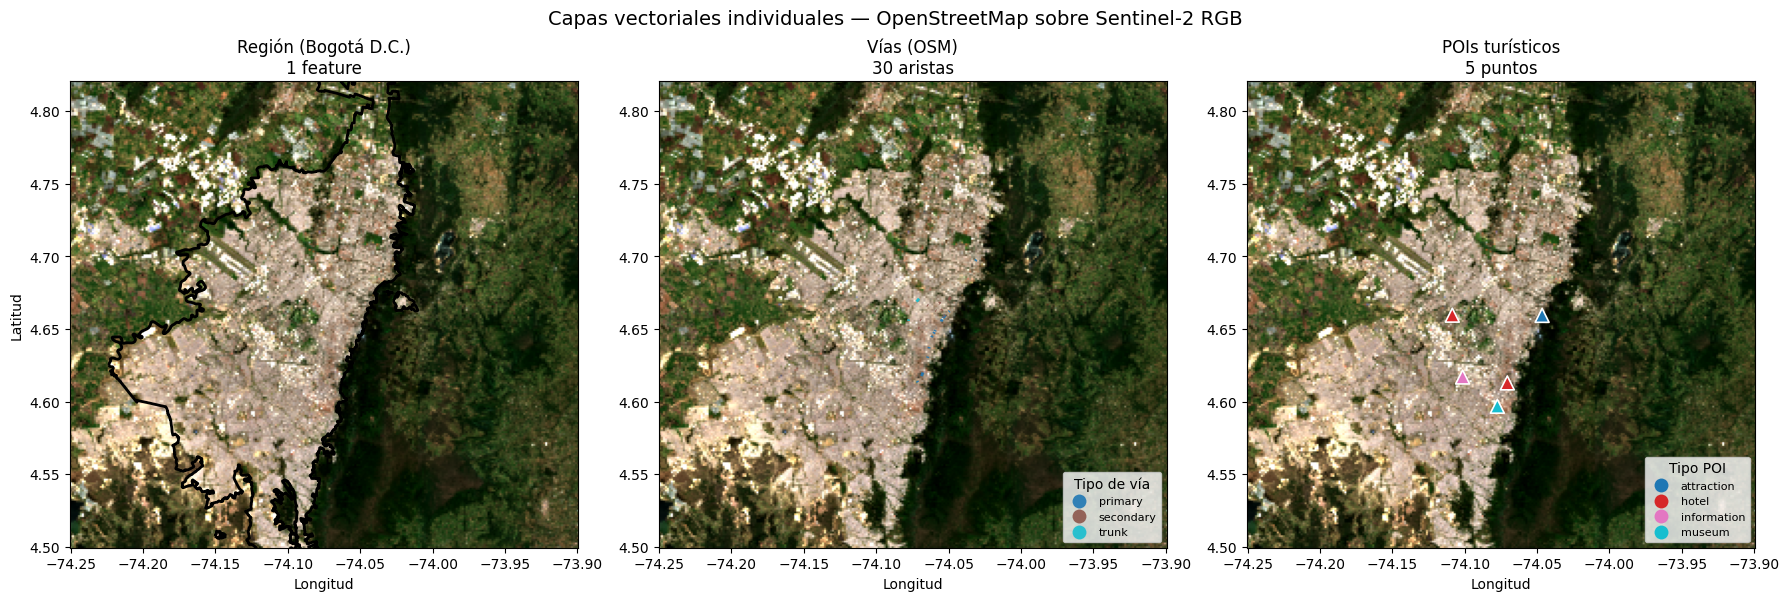

Guardado: /home/bellic12/Desktop/Visual/Semana_13_SLAM_Robotica_Visual/semana_13_2_mapas_interactivos_datos_satelitales/media/04_vectors_separate.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
axes[0].imshow(rgb_stretched, extent=extent)
region.boundary.plot(ax=axes[0], edgecolor="black", linewidth=2)
axes[0].set_title(f"Región (Bogotá D.C.)\n{len(region)} feature")
axes[0].set_xlim(bounds.left, bounds.right)
axes[0].set_ylim(bounds.bottom, bounds.top)
axes[0].set_xlabel("Longitud"); axes[0].set_ylabel("Latitud")

axes[1].imshow(rgb_stretched, extent=extent)
if "highway" in rutas.columns:
    rutas.plot(ax=axes[1], column="highway", linewidth=2, alpha=0.9, legend=True,
               legend_kwds={"title": "Tipo de vía", "loc": "lower right", "fontsize": 8})
else:
    rutas.plot(ax=axes[1], color="orange", linewidth=2, alpha=0.9)
axes[1].set_title(f"Vías (OSM)\n{len(rutas)} aristas")
axes[1].set_xlim(bounds.left, bounds.right)
axes[1].set_ylim(bounds.bottom, bounds.top)
axes[1].set_xlabel("Longitud")

axes[2].imshow(rgb_stretched, extent=extent)
if "tourism" in pois.columns:
    pois.plot(ax=axes[2], column="tourism", markersize=100, marker="^",
              edgecolor="white", linewidth=1.2, legend=True,
              legend_kwds={"title": "Tipo POI", "loc": "lower right", "fontsize": 8})
else:
    pois.plot(ax=axes[2], color="red", markersize=100, marker="^",
              edgecolor="white", linewidth=1.2)
axes[2].set_title(f"POIs turísticos\n{len(pois)} puntos")
axes[2].set_xlim(bounds.left, bounds.right)
axes[2].set_ylim(bounds.bottom, bounds.top)
axes[2].set_xlabel("Longitud")

fig.suptitle("Capas vectoriales individuales — OpenStreetMap sobre Sentinel-2 RGB", fontsize=14)
plt.tight_layout()
out = MEDIA / "04_vectors_separate.png"
plt.savefig(out, dpi=120, bbox_inches="tight")
plt.show()
print(f"Guardado: {out}")

## Conclusiones

- Las 3 capas (región, rutas, POIs) se cargan correctamente desde OSM y se proyectan en EPSG:4326.
- Los POIs y rutas se distribuyen sobre la Sabana de Bogotá en lugares conocidos (centro histórico, Avenida Calle 85, etc.).
- En el notebook 05 estas capas se superponen al NDVI sobre un mapa folium interactivo.